In [1]:
%load_ext autoreload
%autoreload 2
# %env CUDA_VISIBLE_DEVICES=0

## All plots

In [ ]:
import os
import numpy as np
import pandas as pd
from stats_utils import compute_spread, plot_summary

In [ ]:
save_path = './figures/main'


In [ ]:
df0 = pd.read_csv(os.path.join('csv_files', 'regime_decomp.csv'))
df0.head()

,freeze_encoder,survival_head,dev_base,dev_obj,dev_fam,dev_dom,dAIC_obj,dAIC_fam,dAIC_dom
0,0,linear,0.491954,0.760638,0.768407,0.751765,-28.268887,2.019711,8.066761
1,0,mlp,0.516152,0.650928,0.652921,0.630853,-3.009133,3.659965,7.429460
2,1,linear,0.166561,0.896703,0.899129,0.896710,-111.585881,4.256588,3.996081
3,1,mlp,0.122521,0.877002,0.875245,0.877019,-104.247653,5.823179,3.991628


In [ ]:
df = pd.read_csv(os.path.join('csv_files', 'cindex_predictions.csv'))
print(df.columns.tolist())  
print(df.shape)
df.head()

['objective', 'train_size', 'protocol', 'survival_head', 'cindex_fit', 'cindex_se', 'ibs_fit', 'ibs_se', 'level']
(1920, 9)


,objective,train_size,protocol,survival_head,cindex_fit,cindex_se,ibs_fit,ibs_se,level
0,dino,100.000000,fine-tuned,mlp,0.636901,0.022359,0.086854,0.002020,all objectives
1,dino,100.000000,fine-tuned,linear,0.628201,0.022361,0.087918,0.002020,all objectives
2,dino,100.000000,frozen,mlp,0.865049,0.020024,0.075415,0.001976,all objectives
3,dino,100.000000,frozen,linear,0.872648,0.020024,0.069666,0.001905,all objectives
4,dino,110.285255,fine-tuned,mlp,0.637208,0.022328,0.086822,0.002018,all objectives


In [6]:
df.drop_duplicates(subset=['objective', 'protocol', 'train_size', 'survival_head'], keep='first', inplace=True)
print(df.shape)


(1200, 9)


In [ ]:
spread_all = compute_spread(df, "all objectives")

spread_subset = compute_spread(
    df,
    "simclr / mae / dino only",
    objectives=["simclr", "mae", "dino"],
)

spread = pd.concat([spread_all, spread_subset], ignore_index=True)

pred = df.copy()

pred["objective"] = pred["objective"].replace(
    {
        "simclr": "SimCLR",
        "mae": "MAE",
        "dino": "DINOv2",
    }
)

In [12]:
pred.head()

,objective,train_size,protocol,survival_head,cindex_fit,cindex_se,ibs_fit,ibs_se,level
0,DINOv2,100.000000,fine-tuned,mlp,0.636901,0.022359,0.086854,0.002020,all objectives
1,DINOv2,100.000000,fine-tuned,linear,0.628201,0.022361,0.087918,0.002020,all objectives
2,DINOv2,100.000000,frozen,mlp,0.865049,0.020024,0.075415,0.001976,all objectives
3,DINOv2,100.000000,frozen,linear,0.872648,0.020024,0.069666,0.001905,all objectives
4,DINOv2,110.285255,fine-tuned,mlp,0.637208,0.022328,0.086822,0.002018,all objectives


In [ ]:
cindex_top_yticks = np.arange(0.60, 1 + 1e-9, 0.2)  
cindex_bottom_yticks = np.arange(0.0, 0.30 + 1e-9, 0.15)   

cindex_top_yticks

array([0.6, 0.8, 1. ])

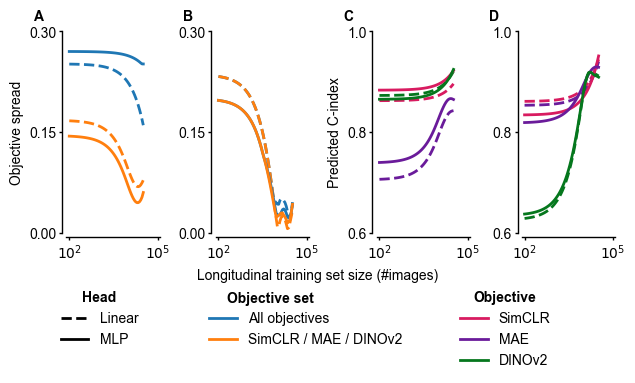

In [ ]:
plot_summary(metric_fit_val = 'cindex_fit',   
                spread_val = 'cindex_spread',
                text_x = -0.35, 
                text_y = 1.11,  
                y_legend=-0.05,     
                legend_below=True,
                top_yticks= cindex_top_yticks, 
                bottom_yticks = cindex_bottom_yticks,
                save_path = os.path.join(save_path, 'obj_summary_c_index'), 
                pred = pred,
                spread = spread
)

In [ ]:
ibs_top_yticks = np.arange(0.049, 0.1 + 1e-9, 0.02)   
ibs_bottom_yticks = np.arange(0.0003, 0.045 + 1e-9, 0.015)   

ibs_bottom_yticks

array([0.0003, 0.0153, 0.0303])

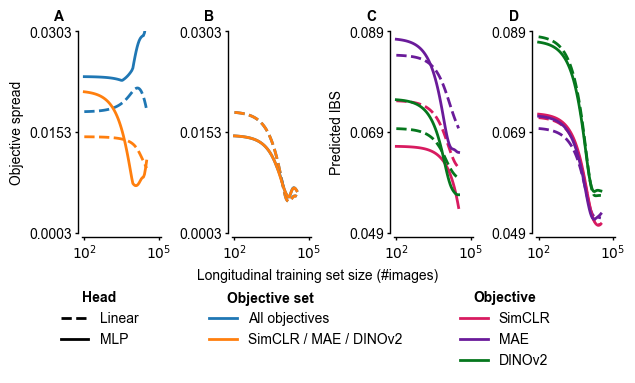

In [ ]:
plot_summary(metric_fit_val = 'ibs_fit',   
            spread_val = 'ibs_spread',
            text_x = -0.35, 
            text_y = 1.11,  
            y_legend=-0.05,         
            legend_below=True,
            top_yticks = ibs_top_yticks,
            bottom_yticks=ibs_bottom_yticks,
            save_path = os.path.join(save_path, 'obj_summary_ibs'), 
            pred = pred,
            spread = spread
)